# Exercise 3 — Sampling from continuous distributions

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t as tdist, chi2, kstwobign

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)
N = 10_000


def ks_test(sample, cdf):                         # KS GoF, all params known
    x = np.sort(sample); n = len(x); i = np.arange(1, n + 1)
    F = cdf(x)
    Dn = max(np.max(i / n - F), np.max(F - (i - 1) / n))
    return dict(Dn=float(Dn), p=float(kstwobign.sf(np.sqrt(n) * Dn)))


def exp_sample(n, lam, rng):
    return -np.log(1.0 - rng.random(n)) / lam


def box_muller(n, rng):
    m = (n + 1) // 2
    U1 = 1.0 - rng.random(m); U2 = rng.random(m)
    R = np.sqrt(-2.0 * np.log(U1))
    Z = np.concatenate([R * np.cos(2 * np.pi * U2), R * np.sin(2 * np.pi * U2)])
    return Z[:n]


def pareto_sample(n, k, beta, rng):               # type I, support [beta, inf): Y = beta U^{-1/k}
    return beta * (1.0 - rng.random(n)) ** (-1.0 / k)


def pareto_cdf(x, k, b):
    return np.where(x >= b, 1 - (b / x) ** k, 0.0)

## Part 1 — Exponential, Normal (Box–Muller), Pareto

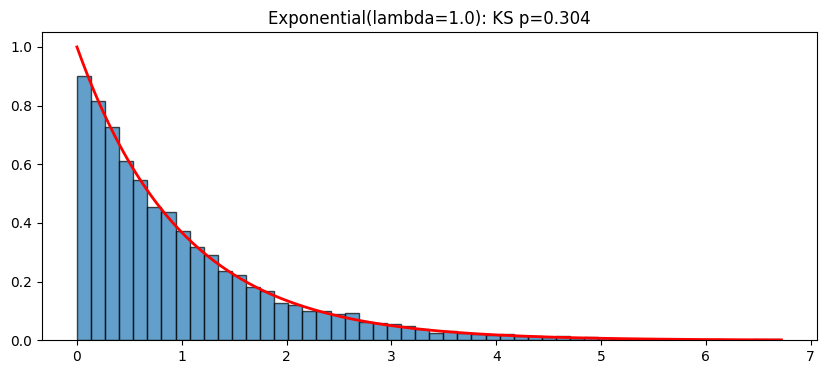

In [2]:
lam = 1.0
s_exp = exp_sample(N, lam, rng)
ks = ks_test(s_exp, lambda x: 1 - np.exp(-lam * x))
xs = np.linspace(0, np.quantile(s_exp, 0.999), 300)
plt.hist(s_exp, bins=50, range=(0, xs[-1]), density=True, alpha=0.7, edgecolor="black")
plt.plot(xs, lam * np.exp(-lam * xs), "r-", lw=2)
plt.title(f"Exponential(lambda={lam}): KS p={ks['p']:.3f}"); plt.show()

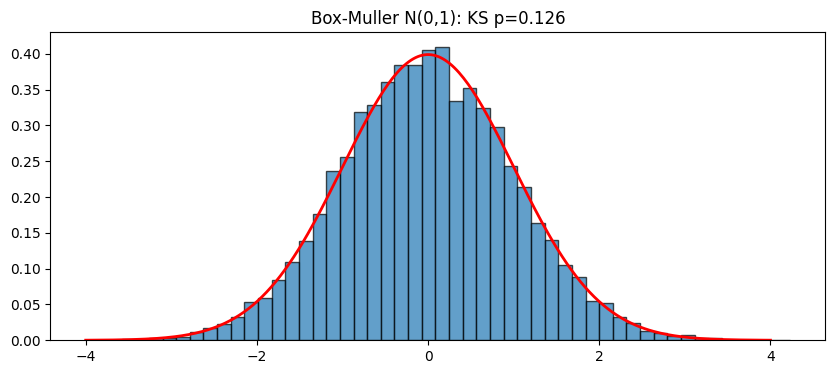

In [3]:
s_norm = box_muller(N, rng)
ks = ks_test(s_norm, norm.cdf)
xs = np.linspace(-4, 4, 300)
plt.hist(s_norm, bins=50, density=True, alpha=0.7, edgecolor="black")
plt.plot(xs, norm.pdf(xs), "r-", lw=2)
plt.title(f"Box-Muller N(0,1): KS p={ks['p']:.3f}"); plt.show()

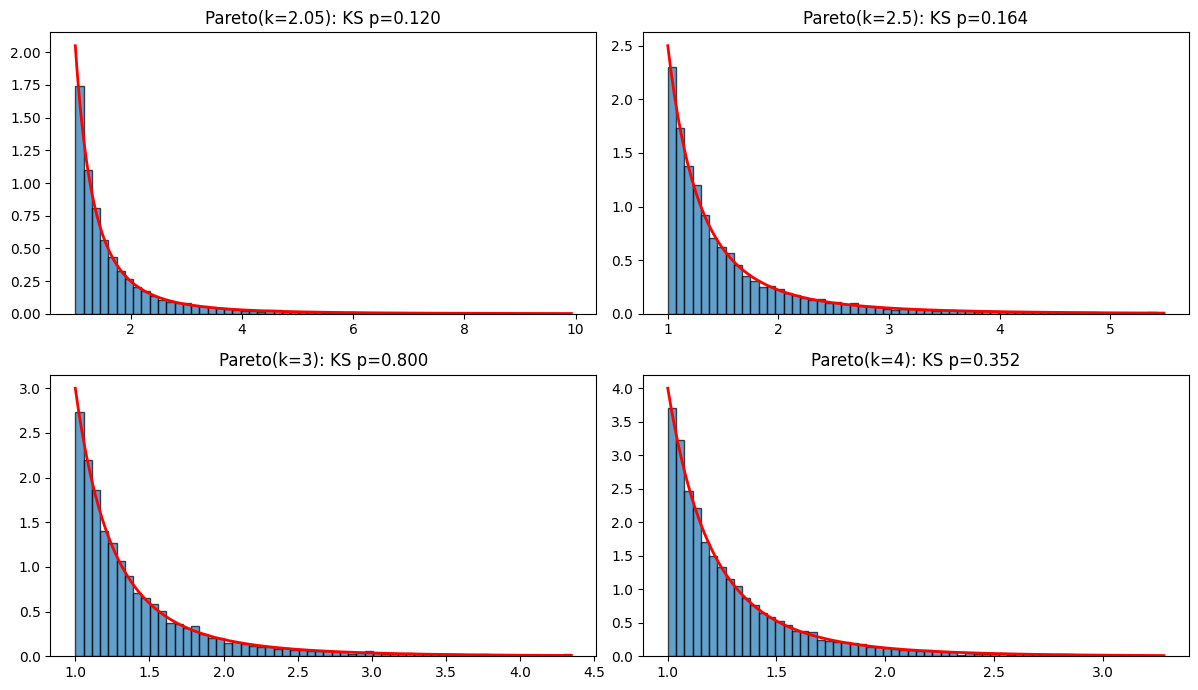

In [4]:
beta = 1.0
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, k in zip(axes.ravel(), [2.05, 2.5, 3, 4]):
    s = pareto_sample(N, k, beta, rng)
    ks = ks_test(s, lambda x, k=k: pareto_cdf(x, k, beta))
    hi = np.quantile(s, 0.99); xs = np.linspace(beta, hi, 300)
    ax.hist(s, bins=60, range=(beta, hi), density=True, alpha=0.7, edgecolor="black")
    ax.plot(xs, k * beta ** k / xs ** (k + 1), "r-", lw=2)
    ax.set_title(f"Pareto(k={k}): KS p={ks['p']:.3f}")
plt.tight_layout(); plt.show()

## Part 2 — Pareto sample mean/variance vs theory

In [5]:
print(f"{'k':>5}{'mean_sim':>10}{'mean_th':>10}{'var_sim':>12}{'var_th':>12}")
for k in [2.05, 2.5, 3, 4]:
    s = pareto_sample(N, k, beta, rng)
    var_th = k / ((k - 1) ** 2 * (k - 2)) if k > 2 else np.inf
    print(f"{k:>5}{s.mean():>10.3f}{k/(k-1):>10.3f}{s.var():>12.3f}{var_th:>12.3f}")

    k  mean_sim   mean_th     var_sim      var_th
 2.05     1.915     1.952       3.861      37.188
  2.5     1.659     1.667       1.410       2.222
    3     1.499     1.500       0.758       0.750
    4     1.332     1.333       0.220       0.222


Mean matches for all k. Variance is unstable for small k: it exists only for k>2, and for k=2.05 the
variance is finite but huge so the estimate converges very slowly.

## Part 3 — 100 confidence intervals (normal, n=10, 95%)

mean CIs covering 0 : 93/100 (nominal 95)
var  CIs covering 1 : 91/100 (nominal 95)


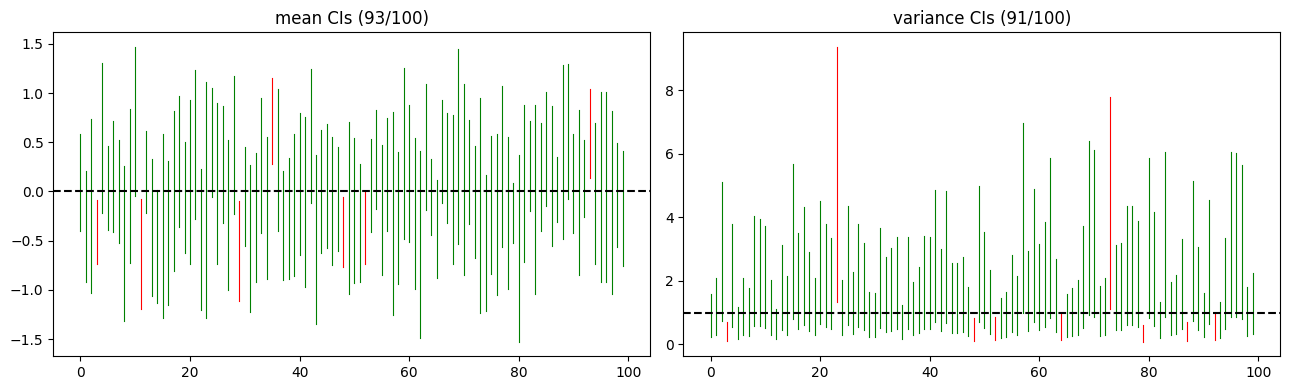

In [6]:
mu, sigma, n, reps = 0.0, 1.0, 10, 100
tcrit = tdist.ppf(0.975, n - 1)
chi_lo, chi_hi = chi2.ppf(0.975, n - 1), chi2.ppf(0.025, n - 1)
cov_mean = cov_var = 0
mean_ci, var_ci = [], []
for _ in range(reps):
    x = mu + sigma * box_muller(n, rng)
    xbar, s2 = x.mean(), x.var(ddof=1)
    lo, hi = xbar - tcrit * np.sqrt(s2 / n), xbar + tcrit * np.sqrt(s2 / n)
    vlo, vhi = (n - 1) * s2 / chi_lo, (n - 1) * s2 / chi_hi
    mean_ci.append((lo, hi)); var_ci.append((vlo, vhi))
    cov_mean += lo <= mu <= hi; cov_var += vlo <= sigma ** 2 <= vhi
print(f"mean CIs covering 0 : {cov_mean}/100 (nominal 95)")
print(f"var  CIs covering 1 : {cov_var}/100 (nominal 95)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for j, ((lo, hi), (vlo, vhi)) in enumerate(zip(mean_ci, var_ci)):
    ax[0].plot([j, j], [lo, hi], color="green" if lo <= 0 <= hi else "red", lw=0.8)
    ax[1].plot([j, j], [vlo, vhi], color="green" if vlo <= 1 <= vhi else "red", lw=0.8)
ax[0].axhline(0, color="black", ls="--"); ax[0].set_title(f"mean CIs ({cov_mean}/100)")
ax[1].axhline(1, color="black", ls="--"); ax[1].set_title(f"variance CIs ({cov_var}/100)")
plt.tight_layout(); plt.show()

Observed coverage fluctuates around the nominal 95% (Monte Carlo error ~2.2% over 100 reps).

## Part 4 — Pareto by composition vs direct inversion

inversion   : mean 1.662 var 1.730 KS p=0.805
composition : mean 1.675 var 2.548 KS p=0.552
theory      : mean 1.667 var 2.222


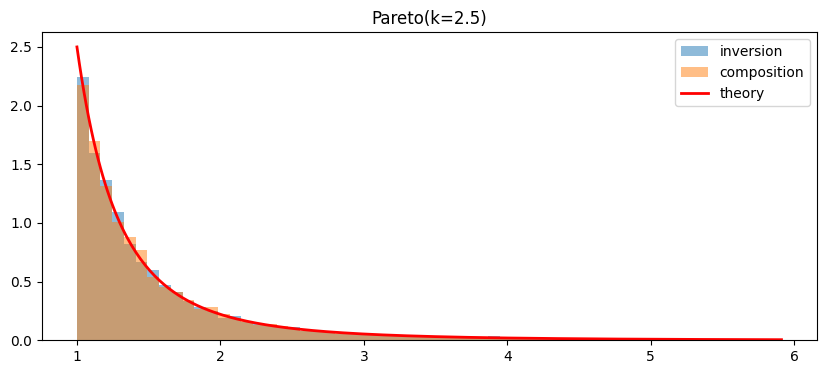

In [7]:
def pareto_composition(n, k, beta, rng):
    lam = rng.gamma(shape=k, scale=1.0 / beta, size=n)   # Lambda ~ Gamma(k, rate beta)
    X = -np.log(1.0 - rng.random(n)) / lam               # X|Lambda ~ Exp(Lambda) -> Lomax
    return beta + X                                      # -> Pareto type I

k = 2.5
s_inv = pareto_sample(N, k, beta, rng)
s_comp = pareto_composition(N, k, beta, rng)
for name, s in [("inversion", s_inv), ("composition", s_comp)]:
    ks = ks_test(s, lambda x: pareto_cdf(x, k, beta))
    print(f"{name:12s}: mean {s.mean():.3f} var {s.var():.3f} KS p={ks['p']:.3f}")
print(f"theory      : mean {k/(k-1):.3f} var {k/((k-1)**2*(k-2)):.3f}")

hi = np.quantile(s_inv, 0.99); xs = np.linspace(beta, hi, 300)
plt.hist(s_inv, bins=60, range=(beta, hi), density=True, alpha=0.5, label="inversion")
plt.hist(s_comp, bins=60, range=(beta, hi), density=True, alpha=0.5, label="composition")
plt.plot(xs, k * beta ** k / xs ** (k + 1), "r-", lw=2, label="theory")
plt.legend(); plt.title(f"Pareto(k={k})"); plt.show()

Both reproduce the same Pareto. Direct inversion (one uniform, closed-form F^{-1}) is simpler and
faster; composition needs an extra Gamma draw, so inversion is preferred here.